# **CS5002 Programming for AI**
# Lab 1: Jupyter and NumPy

This lab introduces you to two fundamental Python tools for data science: Jupyter notebooks and NumPy.

You will start by getting familiar with how to edit and run cells in a Jupyter notebook (like this one), and then explore efficient numerical computations with NumPy, learning how to create arrays, perform vectorised operations, and manipulate data with reshaping and slicing.

These exercises will build towards a foundation for data processing, analysis, and AI workflows in Python.

## Task 1: Getting familiar with Jupyter notebooks

Jupyter notebooks allow you to write executable code, formatted text, and visual output in a single document. They are widely used in data science and machine learning for experimentation and analysis.

Each notebook is made up of cells, which can be:
* Code cells (run your Python code)
* Text cells (write text, headings, equations, etc.)

We'll go over the core functionality you need to know below. For more details, you can check out the Jupyter notebook documentation [here](https://jupyter-notebook.readthedocs.io/en/stable/notebook.html), or this example notebook within Google colab [here](https://colab.research.google.com/notebooks/basic_features_overview.ipynb#scrollTo=JVXnTqyE9RET).

**Text cells**

This cell is a text cell formatted in the Markdown language (https://www.markdownguide.org/basic-syntax/). You can double-click on it to edit it and see the cahnges directly. For example, you can fix that speling error...

**Code cells**

Now let's try to run some code. Below is a code cell. Write a line in Python to print a simple "Hello World!" message. Then press Shift+Enter to execute the code in the cell. You can see how the output of a code cell is shown below the cell itself.

In [1]:
print("Hello World!")


Hello World!


### Adding and Interacting with Cells

Jupyter notebooks are *interactive*.
You can write code, then change it, re-run it, and immediately see the effect in the output.

**To do**

1. Insert a new code cell below this one by hovering your cursor at the end of this cell.
2. Assign a value to a variable (for example, `x = 5`)
3. Print the value of that variable
4. Run the cell using Shift + Enter
5. Change the value and run the cell again

Notice how the output changes when you re-run the cell.

### Variables and Execution Order

In a Jupyter notebook, variables created in one cell are available to later cells, but only if the cell has been run. This makes execution order important.

**To do**

1. Run the two cells below in order. Look at the outputs.
2. Now run the second cell again (and again). The value of `x` is saved between runs.

In [2]:
x = 2
print(f"x = {x}")

x = 2


In [4]:
x = x * 2
print(f"x = {x}")

x = 8


**Important!**

The notebook memory only persists *while the kernel is running*. If you restart the kernel everything is reset.

## Task 2: Vectorisation vs Nested Python Loops

In lecture 2 we learnt about the scientific computing package NumPy. In this task, you’ll see why plain Python loops are slow for numerical computations, and how NumPy lets you perform operations on whole arrays at once, making calculations much faster.

**Objective**

Understand why NumPy vectorisation is faster than nested Python loops.

**To do**

Below is a snippet of pure Python code to do an outer product of two vectors. it uses nested loops to perform all individual multiplications element-wise.

Run the cell below and look at the time taken.

In [5]:
import time
import random

N = 2000

# Create two lists of numbers
a = list(range(N))
b = list(range(N))

# Slow computation using nested loops
start = time.time()

result = [[0.0 for _ in range(N)] for _ in range(N)]
for i in range(N):
    for j in range(N):
        result[i][j] = a[i] * b[j]

end = time.time()
print(f"Time taken (pure Python): {end - start:.2f} seconds")

Time taken (pure Python): 0.43 seconds


### Outer Products

The Python code above is computing the **outer product** between two large lists of numbers. We're just using it as an example of an expensive mathematical computation here, but it's useful to know about so here is an explanation of what's being computed.

Let's say we have two vectors (our lists of numbers):

$$
\mathbf{a} =
\begin{bmatrix}
1 \\
2 \\
3
\end{bmatrix}
\quad
\text{and}
\quad
\mathbf{b} =
\begin{bmatrix}
4 & 5
\end{bmatrix}
$$

The **outer product** of $\mathbf{a}$ and $\mathbf{b}$ is a matrix with all pairwise multiplications:

$$
\mathbf{a}\mathbf{b}
=
\begin{bmatrix}
1 \\
2 \\
3
\end{bmatrix}
\begin{bmatrix}
4 & 5
\end{bmatrix}
=
\begin{bmatrix}
1 \cdot 4 & 1 \cdot 5 \\
2 \cdot 4 & 2 \cdot 5 \\
3 \cdot 4 & 3 \cdot 5
\end{bmatrix}
=
\begin{bmatrix}
4 & 5 \\
8 & 10 \\
12 & 15
\end{bmatrix}
$$

Since $\mathbf{a}$ has three elements and $\mathbf{b}$ has two, the resulting matrix has dimensionality $3 \times 2$. This means for the larger example in our code the resulting matrix has shape $2000 \times 2000$, which requires 4 million individual multiplications!

**Follow up**

Try to increase the `N = 2000` to see how the computation time increases. What is the largest value that computes in under 10 seconds?

### Vectorise with NumPy

You might notice that the code is quite slow... Fortunately, we can make it much much faster by using NumPy!

**NumPy - Numerical Python**, is a package that offers fast operations on multidimensional arrays. The key to this speed is *vectorisation*: parallelising computation and avoiding slow loops. It can be this fast because under the hood NumPy is running your code using optimised, pre-compiled code in the C language. You can check out the NumPy user guide and full documentation for the API [here](https://numpy.org/doc/2.4/index.html). This will be useful for filling in some of the code below.

**To do**

In the cell below, rewrite the computation we saw above using NumPy vectorisation (no Python loops).
1. Convert `a` and `b` into NumPy arrays
2. Compute the same result using NumPy (in only one line!)
3. Compare the execution time

Again, it can be useful to refer to the [NumPy documentation](https://numpy.org/doc/2.4/index.html) and to use the search functionality to find the right piece of code.

In [8]:
import time
import numpy as np

N = 2000

# Create two lists of random numbers
a = list(range(N))
b = list(range(N))

start = time.time()

# 1. Convert a and b to NumPy arrays
a = np.array(a)
b = np.array(b)
# 2. Use NumPy to compute the same result as above (hint: outer product)
result_np = np.outer(a, b)
end = time.time()

assert np.all(np.array(result) == result_np)  # bonus: check that the results are the same

print(f"Time taken (NumPy): {end - start:.4f} seconds")

Time taken (NumPy): 0.0058 seconds


**Follow up**

For this code, what is the largest value that computes in under 10 seconds?

## Task 3: Creating, Reshaping, and Slicing Arrays

Now we will practice some of the core operations with NumPy arrays:
* Creating arrays: We can easily generate sequences of numbers or initial data using functions like `np.arange`, `np.zeros` or `np.ones`.
* Reshaping arrays: We can convert arrays between different shapes (1D, 2D, etc.) without copying data. This is essential for organising data in a way that makes sense for computation or analysis.
* Slicing arrays: Once we have a multi-dimensional array, we can extract subsets of the data easily using Python-style slicing. This is much faster than looping over elements individually.

**Objective**

Practice creating arrays, reshaping them, and extracting sub-arrays.

**To do**

1. Using only `np.arange` and `reshape`, write code to produce the following matrix:
```
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]
 [17 18 19 20]]
```

2. Then use numpy slicing syntax to print only the following subset of the matrix:
```
[[ 5  6  7]
 [ 9 10 11]]
```

In [11]:
import numpy as np

# 1. Create a 1D array using np.arange
arr = np.arange(1, 21)
# 2. Reshape it into a 2D array
arr = np.reshape(arr, (5, 4))
# 3. Use slicing to extract the second matrix
part = arr[1:3, 0:3]
# 4. Print the matrices and compare them to those above
print(arr)
print(part)


[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]
 [17 18 19 20]]
[[ 5  6  7]
 [ 9 10 11]]


## Task 4: Random Numbers, Seeds, and Statistics

In this task, you will learn how to generate random numbers with NumPy and why it is important to set a random seed.

Random data is useful for simulations, testing, and generating synthetic datasets, but results can vary each time unless a seed is set. NumPy uses a pseudo-random number generator (PRNG) to produce sequences of numbers that appear random. The generator is deterministic, so setting a seed ensures that the same sequence of "random" numbers is produced every time, making your results reproducible — essential for debugging, experiments, and sharing analyses.

**Objective**

Learn how to generate reproducible random data and compute summary statistics.

**To do**

Run the cell below twice. You should see different values each time.

In [13]:
import numpy as np

data = np.random.randn(5)
print(data)

[ 0.57801511 -0.42050331 -0.45111045 -0.20333752 -0.7830996 ]


We can ensure we get the same reproducible result by *setting the random seed*. Now run the next cell twice.

In [15]:
np.random.seed(42)
data = np.random.randn(5)
print(data)

[ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]


**Observation:**

Setting a random seed makes the random numbers reproducible. The same thing will happen every time.

*This is critical for debugging, running experiments, and reporting reproducible scientific results!*

### Reproducible Random Matrix and Statistics

NumPy provides functionality for generating random numbers from different statistical distributions, such as the [normal (Gaussian) distribution](https://en.wikipedia.org/wiki/Normal_distribution), see figure below.

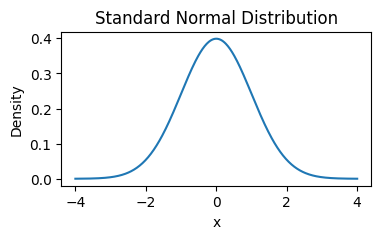

In this exercise, you will generate a $1000 \times 100$ matrix of random numbers from a normal distribution, set a random seed for reproducibility, and compute basic summary statistics (minimum, maximum, mean, median, and standard deviation) to explore the data.

**To do**

1. Import the NumPy package
2. Set the random seed to $0$
3. Generate a $1000 \times 100$ matrix of random numbers from a normal distribution
4. Compute and print the following statistics:
    * Minimum
    * Maximum
    * Mean
    * Median
    * Standard deviation

In [18]:
# 1. Import NumPy
import numpy as np
# 2. Set the random seed to 0
np.random.seed(0)
# 3. Generate the random matrix
X = np.random.randn(1000, 100)
# 4. Compute the statistics
min_value = np.min(X)
max_value = np.max(X)
mean_value = np.mean(X)
median_value = np.median(X)
std_value = np.std(X)

print("Min:", min_value)
print("Max:", max_value)
print("Mean:", mean_value)
print("Median:", median_value)
print("Standard deviation:", std_value)

Min: -4.852117653180117
Max: 4.241771912903697
Mean: 0.0015767005081253388
Median: 0.0017202220855813645
Standard deviation: 0.9973396878273816


**Follow up**

Why is it important to set a random seed in:
* Scientific experiments?
* Machine learning training?
* Debugging numerical code?

Write a sentence for each, or discuss with a fellow student.

## Task 5: Splitting Data into Train, Validation, and Test Sets

In machine learning workflows, data is typically split into training, validation, and test sets.
* The training set is used to fit a model
* The validation set is used to tune parameters and make design choices
* The test set is held out and used only for final evaluation

In this task, you will shuffle and split the synthetic dataset you just created into these three subsets using NumPy.

**To do**

Using your data matrix X from before, we will split it into three sets.

1. Set the random seed to ensure the split is reproducible.
2. Randomly shuffle the rows of X
3. Split the data into:
    * 70% training
    * 15% validation
    * 15% test
4. Print the shape and statistics of each split

In [20]:
import numpy as np

# Assume X has shape (1000, 100) - you might need to rename it above

# 1. Set the random seed
np.random.seed(0)
# 2. Shuffle the data along the first axis
np.random.shuffle(X)  # note this modifies the original array X in place
# 3. Split X into X_train, X_val, and X_test
X_train = X[:700]
X_val = X[700:850]
X_test = X[850:]
# 4. Print the shapes and statistics of each split
def print_stats(split):
    print(f"  Shape: {split.shape}")
    print("  Min:", np.min(split))
    print("  Max:", np.max(split))
    print("  Mean:", np.mean(split))
    print("  Median:", np.median(split))
    print("  Standard deviation:", np.std(split))
print("X_train stats:")
print_stats(X_train)
print("X_val stats:")
print_stats(X_val)
print("X_test stats:")
print_stats(X_test)


X_train stats:
  Shape: (700, 100)
  Min: -4.852117653180117
  Max: 4.241771912903697
  Mean: 0.001665156642782228
  Median: 0.00036086734293344885
  Standard deviation: 0.9951425914841113
X_val stats:
  Shape: (150, 100)
  Min: -3.740100637951779
  Max: 3.8448247444424077
  Mean: -0.005930385487114351
  Median: 0.0014284764931549376
  Standard deviation: 1.0017764779316054
X_test stats:
  Shape: (150, 100)
  Min: -4.4466322413592945
  Max: 4.019773551097265
  Mean: 0.008670991208299545
  Median: 0.007210113583697767
  Standard deviation: 1.0030649155224833


**Follow up**

Are the statistics (mean, median, standard deviation etc.) similar across the splits?

Is it important in a machine learning project that the train/val/test splits have similar statistical properties? Write down an answer or discuss with a fellow student.

## Summary

In this lab we have learnt the basics of Jupyter notebooks and processing data with NumPy. You should now know how to:
1. Edit and run text and code cells in a Jupyter notebook.
2. Write fast NumPy code that uses vectorisation.
3. Create, reshape, index and slice n-dimensional arrays in NumPy.
4. Generate random data, report statistics and set random seeds.
5. Shuffle data and split it into training, validation and test sets.

In the next lab we will focus on understanding and visualising data using `pandas` and `matplotlib`.

## Extra Task: Complex manipulation of matrices

If you've completed the main tasks of this lab, it's time to put your artistic (and coding) talents to the test! In the task below you can play around with manipulating matrices in different ways to create a beautiful natural scene.

The code cell below defines four binary matrices (containing just 1s and 0s). Run the cell and move on to the next.

In [22]:
import numpy as np

bird = np.array([
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0,
    0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
    0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
    0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
    0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
    0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0,
    0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
    0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
]).reshape(16, 16)

tree = np.array([
    0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
    0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
    0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
    0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0
]).reshape(16, 16)

cloud = np.array([
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
    0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
    0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
]).reshape(16, 16)

sun = np.array([
    0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
    0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
    0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
    0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
    0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
    1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
    0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
    0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
    0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
    0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
    0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
]).reshape(16, 16)

### Plotting the matrices as images

We can treat the binary matrices as black and white images and plot them in our notebook. They will depict different objects (🐦, 🌲, ☁️, ☀️).

**Objective**

Make the most beautiful nature scene using these matrices.

**To do**

1. Run the code below to plot the first example scene
2. Use NumPy operations to make a more complex scene! You may wish to:
    * Make the scene bigger (e.g. 128x128 pixels) to add more space between objects
    * Add duplicates of e.g. trees or clouds (make sure the objects don't override each other but add)
    * Flip or rotate an object (using e.g. `np.flip()` and `np.rot90()`)
    * Scale an object up or down in size (using `np.repeat()` or array slicing)
    * You can even make colours if you do your own research (hint: you will need three channels matching RGB)

Next lab will focus more on plotting and visualising data!

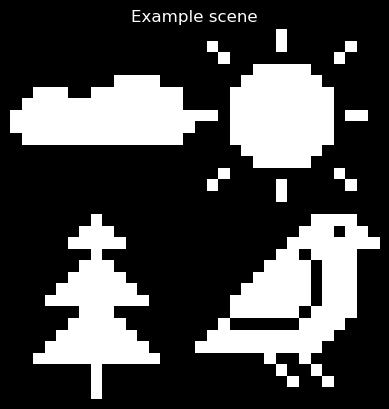

In [23]:
import matplotlib.pyplot as plt

# Helper function to plot the scene
def plot_scene(canvas, title=""):
    plt.imshow(canvas, cmap="gray", origin="upper")
    plt.axis("off")
    plt.title(title)
    plt.show()

# Starter scene canvas
scene = np.zeros((32, 32))  # 32x32 blank canvas

# Place cloud at top-left
scene[:16, :16] = cloud

# Place tree at bottom-left
scene[16:, :16] = tree

# Place sun at top-right
scene[:16, 16:] = sun

# Place bird bottom-right
scene[16:, 16:] = bird

plot_scene(scene, "Example scene")

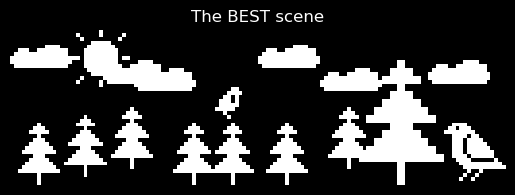

In [79]:
# Scene canvas
scene = np.zeros((40, 128))  # 40x128 blank canvas

def place(what, row, col):
    h, w = what.shape
    scene[row : row + h, col : col + w] = np.maximum(what, scene[row : row + h, col : col + w])

# Place clouds
place(cloud, 0, 0)
place(cloud, 4, 24)
place(cloud, 6, 32)
place(cloud, 0, 64)
place(cloud, 6, 80)
place(cloud, 4, 108)

# Place trees
big_tree = np.repeat(np.repeat(tree, 2, 0), 2, 1)
place(tree, 24, 0)
place(tree, 22, 12)
place(tree, 20, 24)
place(tree, 24, 40)
place(tree, 24, 50)
place(tree, 24, 64)
place(tree, 20, 80)
place(big_tree, 8, 86)

# Place sun
place(sun, 0, 16)

# Place birds
small_bird = bird[::2, ::2]
leftward_bird = np.flip(bird, 1)
place(small_bird, 16, 53)
place(leftward_bird, 24, 112)

plot_scene(scene, "The BEST scene")

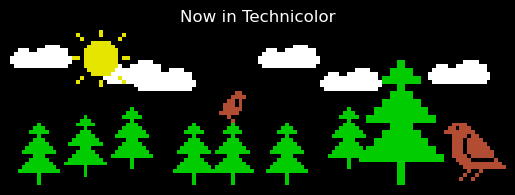

In [85]:
# Scene canvas
scene = np.zeros((40, 128, 3))  # 40x128 blank canvas, three colour channels

def place(what, row, col, rgb):
    h, w = what.shape
    coloured_thing = what.reshape(h, w, 1) * rgb  # recolour the black-and-white thing
    scene[row : row + h, col : col + w, :] = np.where(what.reshape(h, w, 1) > 0, coloured_thing, scene[row : row + h, col : col + w])  # overlay it into the scene

# Place clouds
place(cloud, 0, 0, [1, 1, 1])
place(cloud, 4, 24, [1, 1, 1])
place(cloud, 6, 32, [1, 1, 1])
place(cloud, 0, 64, [1, 1, 1])
place(cloud, 6, 80, [1, 1, 1])
place(cloud, 4, 108, [1, 1, 1])

# Place trees
big_tree = np.repeat(np.repeat(tree, 2, 0), 2, 1)
place(tree, 24, 0, [0, 0.8, 0])
place(tree, 22, 12, [0, 0.8, 0])
place(tree, 20, 24, [0, 0.8, 0])
place(tree, 24, 40, [0, 0.8, 0])
place(tree, 24, 50, [0, 0.8, 0])
place(tree, 24, 64, [0, 0.8, 0])
place(tree, 20, 80, [0, 0.8, 0])
place(big_tree, 8, 86, [0, 0.8, 0])

# Place sun
place(sun, 0, 16, [0.9, 0.9, 0])

# Place birds
small_bird = bird[::2, ::2]
leftward_bird = np.flip(bird, 1)
place(small_bird, 16, 53, [0.7, 0.3, 0.2])
place(leftward_bird, 24, 112, [0.7, 0.3, 0.2])

plot_scene(scene, "Now in Technicolor")